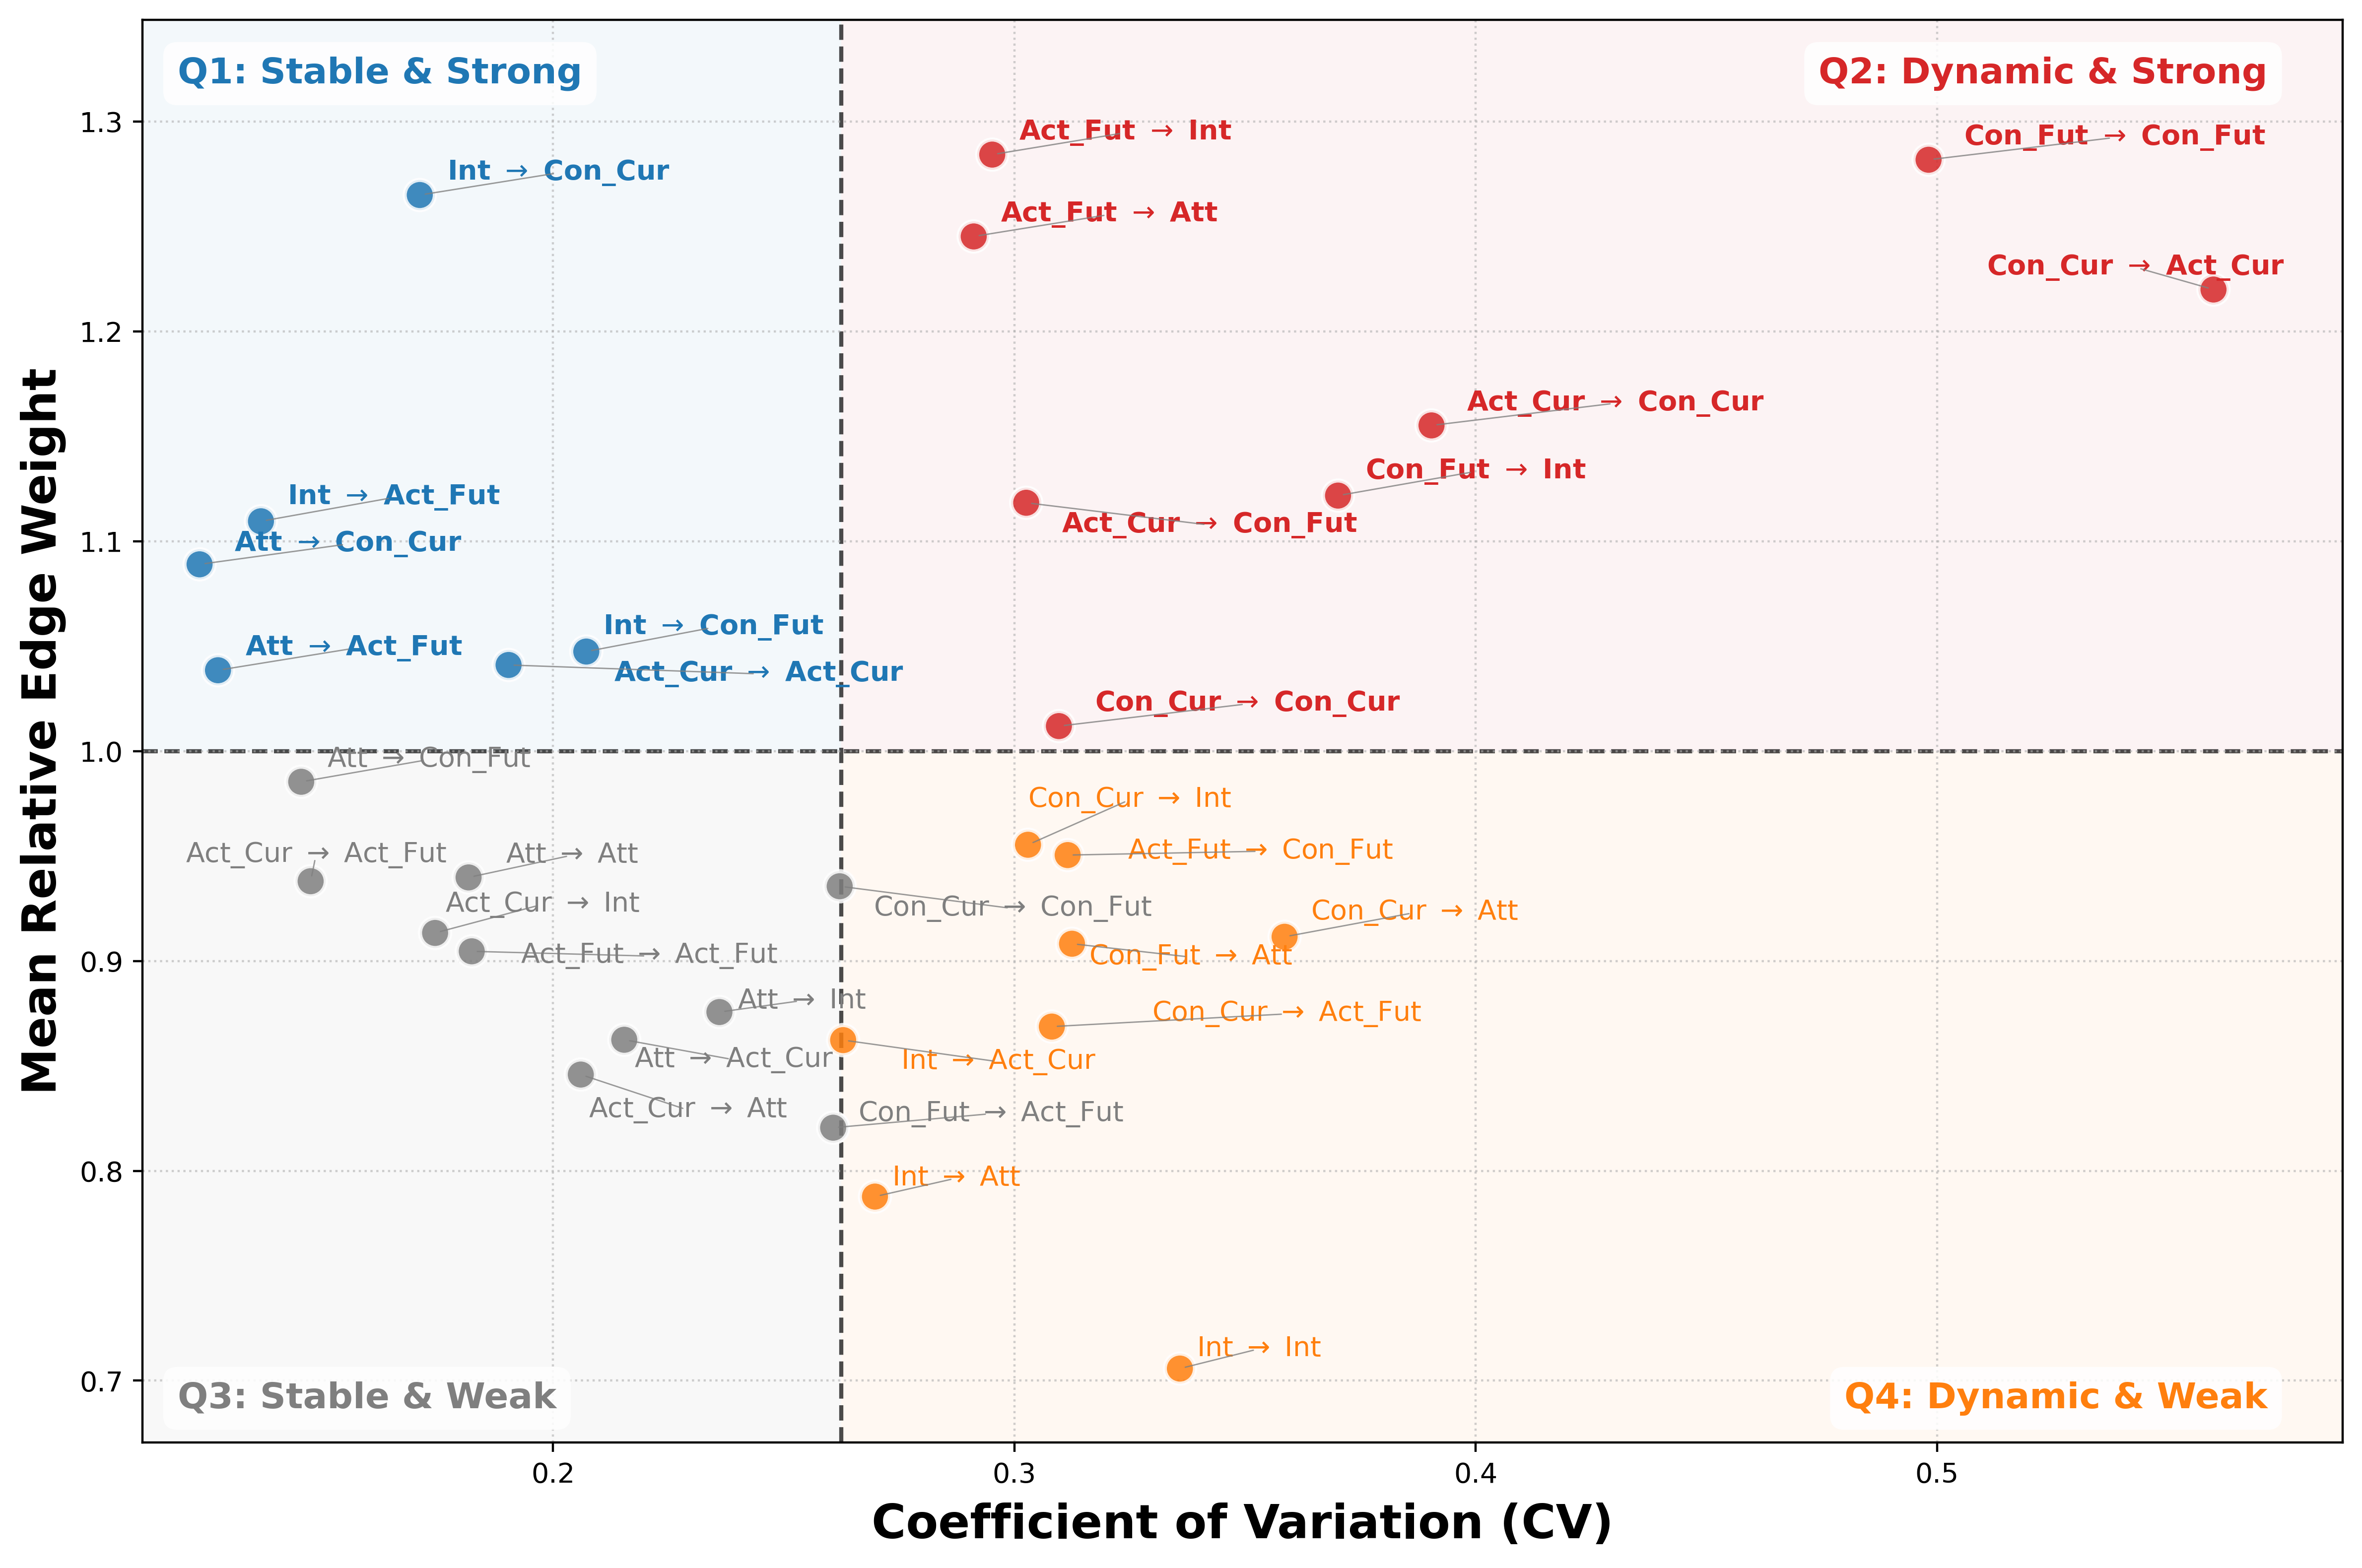

In [2]:
! pip install adjustText
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
try:
    from adjustText import adjust_text
except ImportError:
    adjust_text = None

# ==========================================
# 1. Loading data
# ==========================================
try:
    df = pd.read_csv('matrices_uncertainty.csv')
except FileNotFoundError:
    print("Error: No matrices_uncertainty.csv，please check path.")
    raise

tasks = ['Contact_Current', 'Contact_Future', 'Intent', 'Attitude', 'Action_Current', 'Action_Future']
short_names = {'Contact_Current': 'Con_Cur', 'Contact_Future': 'Con_Fut',
               'Intent': 'Int', 'Attitude': 'Att',
               'Action_Current': 'Act_Cur', 'Action_Future': 'Act_Fut'}

masked_edges = [
    ('Contact_Future', 'Contact_Current'), ('Contact_Future', 'Action_Current'),
    ('Action_Future', 'Contact_Current'), ('Action_Future', 'Action_Current')
]

valid_cols = [f'Weight_{s}_to_{d}' for s in tasks for d in tasks if (s,d) not in masked_edges if f'Weight_{s}_to_{d}' in df.columns]
df['Global_Avg_Weight'] = df[valid_cols].mean(axis=1)

# ==========================================
# 2. Calculate relative weights and coefficient of variation
# ==========================================
edges_data = []
for s in tasks:
    for d in tasks:
        if (s, d) not in masked_edges:
            w_col = f'Weight_{s}_to_{d}'
            if w_col in df.columns:
                rel_weight = df[w_col] / (df['Global_Avg_Weight'] + 1e-9)
                mean_w = rel_weight.mean()
                std_w = rel_weight.std()
                cv_w = std_w / (mean_w + 1e-9)

                edges_data.append({
                    'Edge': f"{short_names[s]} $\\rightarrow$ {short_names[d]}",
                    'Mean_Weight': mean_w,
                    'CV': cv_w
                })

df_edges = pd.DataFrame(edges_data)

# ==========================================
# 3. Setting thresholds for quadrant division
# ==========================================
y_mid = 1.0
x_mid = df_edges['CV'].median()

x_min, x_max = df_edges['CV'].min() * 0.9, df_edges['CV'].max() * 1.05
y_min, y_max = df_edges['Mean_Weight'].min() * 0.95, df_edges['Mean_Weight'].max() * 1.05

# ==========================================
# 4. Draw scatter plot
# ==========================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=400)

colors = []
for _, row in df_edges.iterrows():
    if row['CV'] <= x_mid and row['Mean_Weight'] >= y_mid:
        colors.append('#1f77b4')
    elif row['CV'] > x_mid and row['Mean_Weight'] >= y_mid:
        colors.append('#d62728')
    elif row['CV'] <= x_mid and row['Mean_Weight'] < y_mid:
        colors.append('#7f7f7f')
    else:
        colors.append('#ff7f0e')

scatter = ax.scatter(df_edges['CV'], df_edges['Mean_Weight'],
                     c=colors, s=120, alpha=0.85, edgecolors='white', linewidth=1.5, zorder=3)

ax.axhline(y_mid, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
ax.axvline(x_mid, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)

ax.axhspan(y_mid, y_max, xmin=0, xmax=(x_mid-x_min)/(x_max-x_min), facecolor='#1f77b4', alpha=0.05, zorder=0)
ax.axhspan(y_mid, y_max, xmin=(x_mid-x_min)/(x_max-x_min), xmax=1, facecolor='#d62728', alpha=0.05, zorder=0)
ax.axhspan(y_min, y_mid, xmin=0, xmax=(x_mid-x_min)/(x_max-x_min), facecolor='#7f7f7f', alpha=0.05, zorder=0)
ax.axhspan(y_min, y_mid, xmin=(x_mid-x_min)/(x_max-x_min), xmax=1, facecolor='#ff7f0e', alpha=0.05, zorder=0)

# ==========================================
# 5. Add text labels and resolve occlusions
# ==========================================
texts = []
for i, row in df_edges.iterrows():
    c = colors[i]
    fw = 'bold' if row['Mean_Weight'] >= y_mid else 'normal'
    texts.append(ax.text(row['CV'], row['Mean_Weight'], row['Edge'],
                         color=c, fontsize=10, fontweight=fw))

if adjust_text:
    adjust_text(texts,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.8),
                expand_points=(1.2, 1.2),
                force_points=(0.5, 0.5),
                force_text=(0.5, 0.5))

# ==========================================
# 6. Visualisation
# ==========================================
props = dict(boxstyle='round,pad=0.4', edgecolor='none', alpha=0.85)

ax.text(x_min + (x_mid - x_min)*0.05, y_max - (y_max - y_mid)*0.05,
        'Q1: Stable & Strong',
        fontsize=13, fontweight='bold', color='#1f77b4', bbox=dict(facecolor='white', **props), va='top')

ax.text(x_max - (x_max - x_mid)*0.05, y_max - (y_max - y_mid)*0.05,
        'Q2: Dynamic & Strong',
        fontsize=13, fontweight='bold', color='#d62728', bbox=dict(facecolor='white', **props), ha='right', va='top')

ax.text(x_min + (x_mid - x_min)*0.05, y_min + (y_mid - y_min)*0.05,
        'Q3: Stable & Weak',
        fontsize=13, fontweight='bold', color='#7f7f7f', bbox=dict(facecolor='white', **props))

ax.text(x_max - (x_max - x_mid)*0.05, y_min + (y_mid - y_min)*0.05,
        'Q4: Dynamic & Weak',
        fontsize=13, fontweight='bold', color='#ff7f0e', bbox=dict(facecolor='white', **props), ha='right')

ax.set_xlabel('Coefficient of Variation (CV)',
              fontsize=17, fontweight='bold', labelpad=5)
ax.set_ylabel('Mean Relative Edge Weight',
              fontsize=17, fontweight='bold', labelpad=5)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.grid(True, linestyle=':', alpha=0.6, zorder=0)

plt.tight_layout()
plt.savefig('relative_weight_vs_cv.png', transparent=True, bbox_inches='tight', pad_inches=0,dpi=400)
plt.show()

/tmp/ipykernel_3871/668646500.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['Video_ID', 'Stage_Label'], group_keys=False).apply(normalize_time)


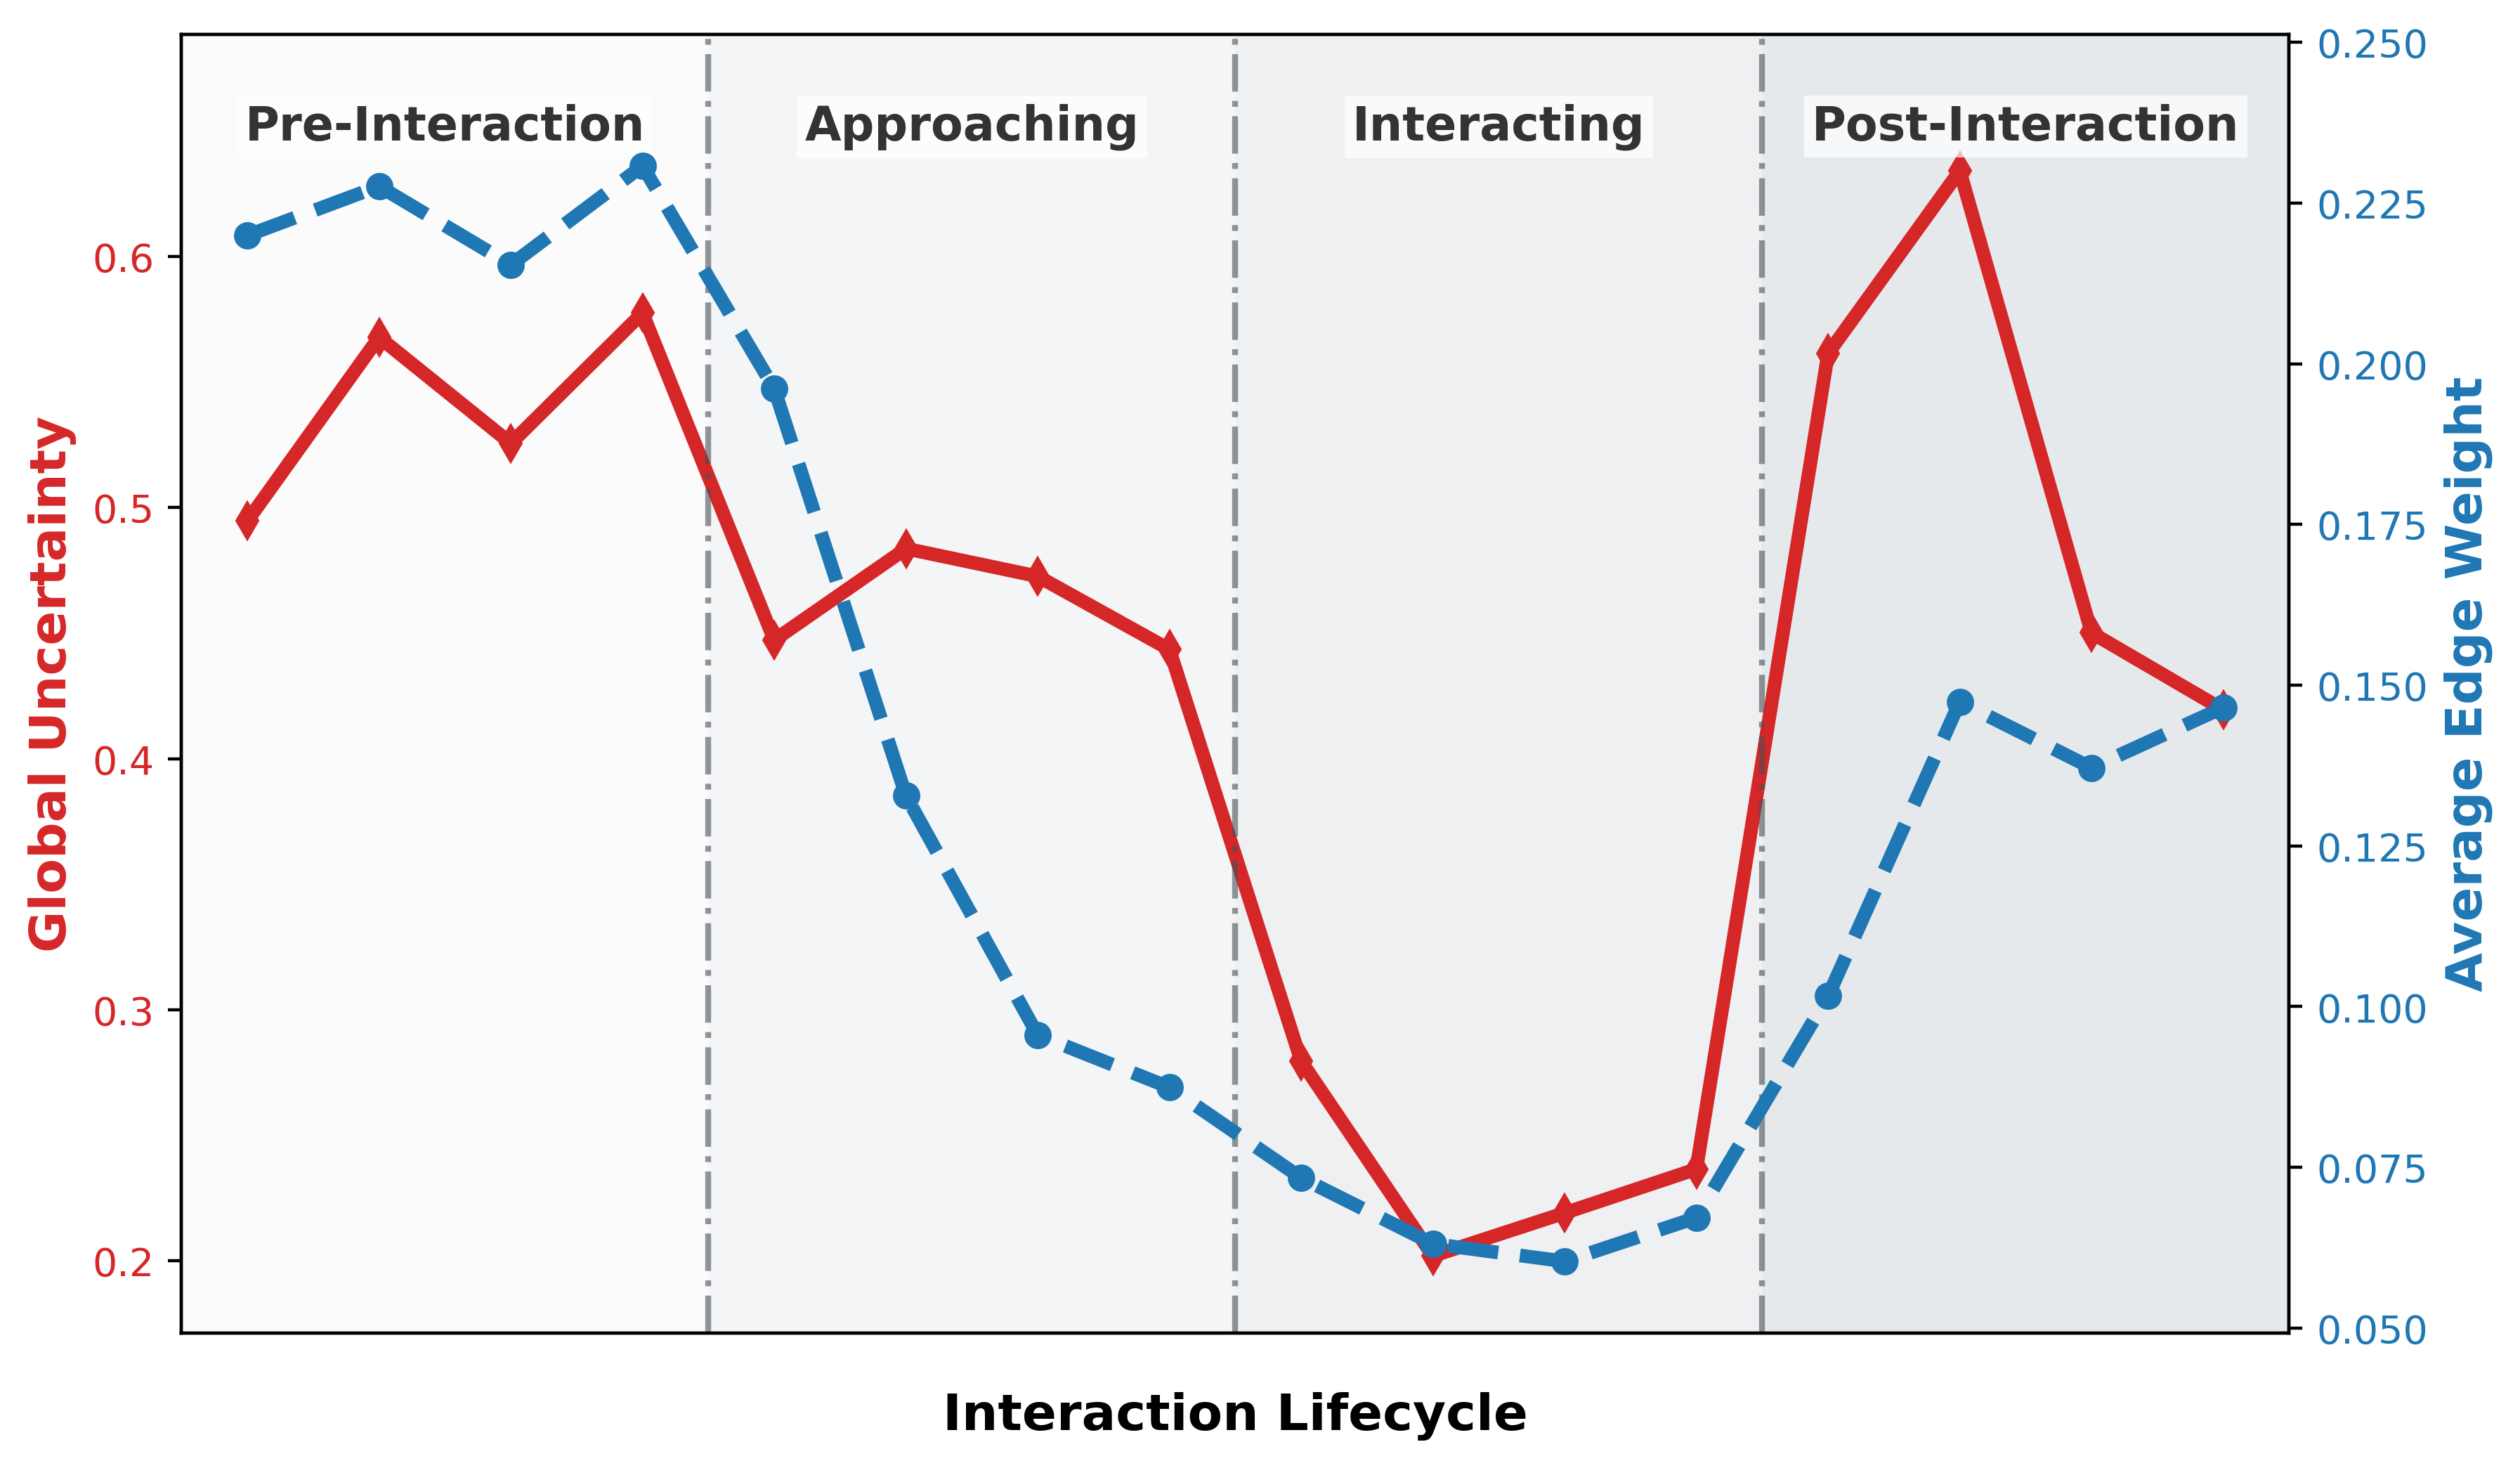

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. Loading data
try:
    df = pd.read_csv('matrices_uncertainty.csv')
except FileNotFoundError:
    print("Error: No matrices_uncertainty.csv，please check path.")
    raise

tasks = ['Contact_Current', 'Contact_Future', 'Intent', 'Attitude', 'Action_Current', 'Action_Future']

# 2.  Parsing Sample_ID
def parse_sample_id(sid):
    sid_str = str(sid)
    if 'json' in sid_str:
        parts = sid_str.split('json')
        video_id = parts[0].strip('_')
        timestamp_str = re.sub(r'\D', '', parts[1])
        timestamp = int(timestamp_str) if timestamp_str else 0
    else:
        video_id = 'unknown_video'
        timestamp = 0
    return pd.Series([video_id, timestamp])

df[['Video_ID', 'Timestamp']] = df['Sample_ID'].apply(parse_sample_id)

# 3. Calculate the absolute average weight (Global) and the relative output weight
masked_edges = [('Contact_Future', 'Contact_Current'), ('Contact_Future', 'Action_Current'),
                ('Action_Future', 'Contact_Current'), ('Action_Future', 'Action_Current')]

valid_cols = []
for src in tasks:
    for dst in tasks:
        if src != dst and (src, dst) not in masked_edges:
            col_name = f'Weight_{src}_to_{dst}'
            if col_name in df.columns:
                valid_cols.append(col_name)

df['Global_Avg_Weight'] = df[valid_cols].mean(axis=1)

current_sources = ['Action_Current','Contact_Current']
targets = ['Contact_Future', 'Action_Future', 'Intent', 'Attitude']
out_cols = [f'Weight_{src}_to_{dst}' for src in current_sources for dst in targets if f'Weight_{src}_to_{dst}' in df.columns]

df['Current_Output_Raw'] = df[out_cols].mean(axis=1)
df['Relative_Current_Output'] = df['Current_Output_Raw'] / (df['Global_Avg_Weight'] + 1e-9)

uncertainty_cols = [
    'Uncertainty_Entropy_Contact_Current_graph',
    'Uncertainty_Entropy_Contact_Future_graph',
    'Uncertainty_Entropy_Intent_graph',
    'Uncertainty_Entropy_Attitude_graph',
    'Uncertainty_Entropy_Action_Current_graph',
    'Uncertainty_Entropy_Action_Future_graph'
]

valid_uncert_cols = [col for col in uncertainty_cols if col in df.columns]

if valid_uncert_cols:
    df['Mean_Predictive_Uncertainty'] = df[valid_uncert_cols].mean(axis=1)
else:
    df['Mean_Predictive_Uncertainty'] = np.nan


# 4. Phase definition and time normalisation
stage_order = ['Pre-Interaction', 'Approaching', 'Interacting', 'Post-Interaction']
df = df[df['Stage_Label'].isin(stage_order)].copy()

stage_mapping = {stage: i for i, stage in enumerate(stage_order)}
df['Stage_Order'] = df['Stage_Label'].map(stage_mapping)

def normalize_time(group):
    if len(group) <= 1 or group['Timestamp'].max() == group['Timestamp'].min():
        group['Norm_Time'] = 0.5
    else:
        min_t = group['Timestamp'].min()
        max_t = group['Timestamp'].max()
        group['Norm_Time'] = (group['Timestamp'] - min_t) / (max_t - min_t)
    return group

df = df.groupby(['Video_ID', 'Stage_Label'], group_keys=False).apply(normalize_time)

# 5. Fine-grained binning
BINS_PER_STAGE = 4
TOTAL_BINS = len(stage_order) * BINS_PER_STAGE

df['Bin_Index'] = (df['Norm_Time'] * (BINS_PER_STAGE - 1)).round().astype(int)
df['Global_Timeline'] = df['Stage_Order'] * BINS_PER_STAGE + df['Bin_Index']

timeline_stats = df.groupby('Global_Timeline').agg(
    Avg_Global_Weight=('Global_Avg_Weight', 'mean'),
    Avg_Rel_Current_Out=('Relative_Current_Output', 'mean'),
    Avg_Predictive_Uncertainty=('Mean_Predictive_Uncertainty', 'mean')
)

timeline_stats = timeline_stats.reindex(range(TOTAL_BINS))
for col in timeline_stats.columns:
    timeline_stats[col] = timeline_stats[col].interpolate(method='linear', limit_direction='both')
timeline_stats['Global_Timeline'] = timeline_stats.index

approaching_start = 1 * BINS_PER_STAGE
approaching_end = (1 + 1) * BINS_PER_STAGE
reversed_values = timeline_stats.loc[approaching_start : approaching_end - 1, 'Avg_Predictive_Uncertainty'].values[::-1]
timeline_stats.loc[approaching_start : approaching_end - 1, 'Avg_Predictive_Uncertainty'] = reversed_values

# 6. Start drawing on four axes
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=400)
fig.subplots_adjust(right=0.75)
x = timeline_stats['Global_Timeline']

color_uncert = '#d62728'
line1, = ax1.plot(x, timeline_stats['Avg_Predictive_Uncertainty'], color=color_uncert, linewidth=3.5, marker='d', markersize=6, linestyle='-', label='Global Uncertainty (MC Entropy)')
ax1.set_xlabel('Interaction Lifecycle', fontsize=13, fontweight='bold', labelpad=15)
ax1.set_ylabel('Global Uncertainty', color=color_uncert, fontsize=13, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_uncert)

ax2 = ax1.twinx()
color_weight = '#1f77b4'
line2, = ax2.plot(x, timeline_stats['Avg_Global_Weight'], color=color_weight, linewidth=3.5, marker='o', markersize=6, linestyle='--', label='Avg. edge weight')
ax2.set_ylabel('Average Edge Weight', color=color_weight, fontsize=13, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_weight)

ax1.set_ylim(ax1.get_ylim()[0] * 0.95, ax1.get_ylim()[1] * 1.05)
ax2.set_ylim(ax2.get_ylim()[0] * 0.95, ax2.get_ylim()[1] * 1.05)

# 7. Add stage dividers and background colouring
colors = ['#f8f9fa', '#e9ecef', '#dee2e6', '#ced4da']

for i in range(len(stage_order)):
    start_x = i * BINS_PER_STAGE - 0.5
    end_x = (i + 1) * BINS_PER_STAGE - 0.5
    ax1.axvspan(start_x, end_x, facecolor=colors[i], alpha=0.5)

    center_x = i * BINS_PER_STAGE + (BINS_PER_STAGE - 1) / 2
    ax1.text(center_x, ax1.get_ylim()[1] * 0.96, stage_order[i],
             ha='center', va='top', fontsize=12, fontweight='bold', color='#333',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

    if i > 0:
        ax1.axvline(x=start_x, color='#495057', linestyle='-.', linewidth=1.5, alpha=0.6)

lines = [line1, line2]
labels = [l.get_label() for l in lines]

ax1.set_xlim(-0.5, TOTAL_BINS - 0.5)
ax1.set_xticks([])
plt.grid(False)

plt.savefig('interaction_lifecycle.png', transparent=True, bbox_inches='tight', pad_inches=0,dpi=400)
plt.show()

Plot saved successfully.


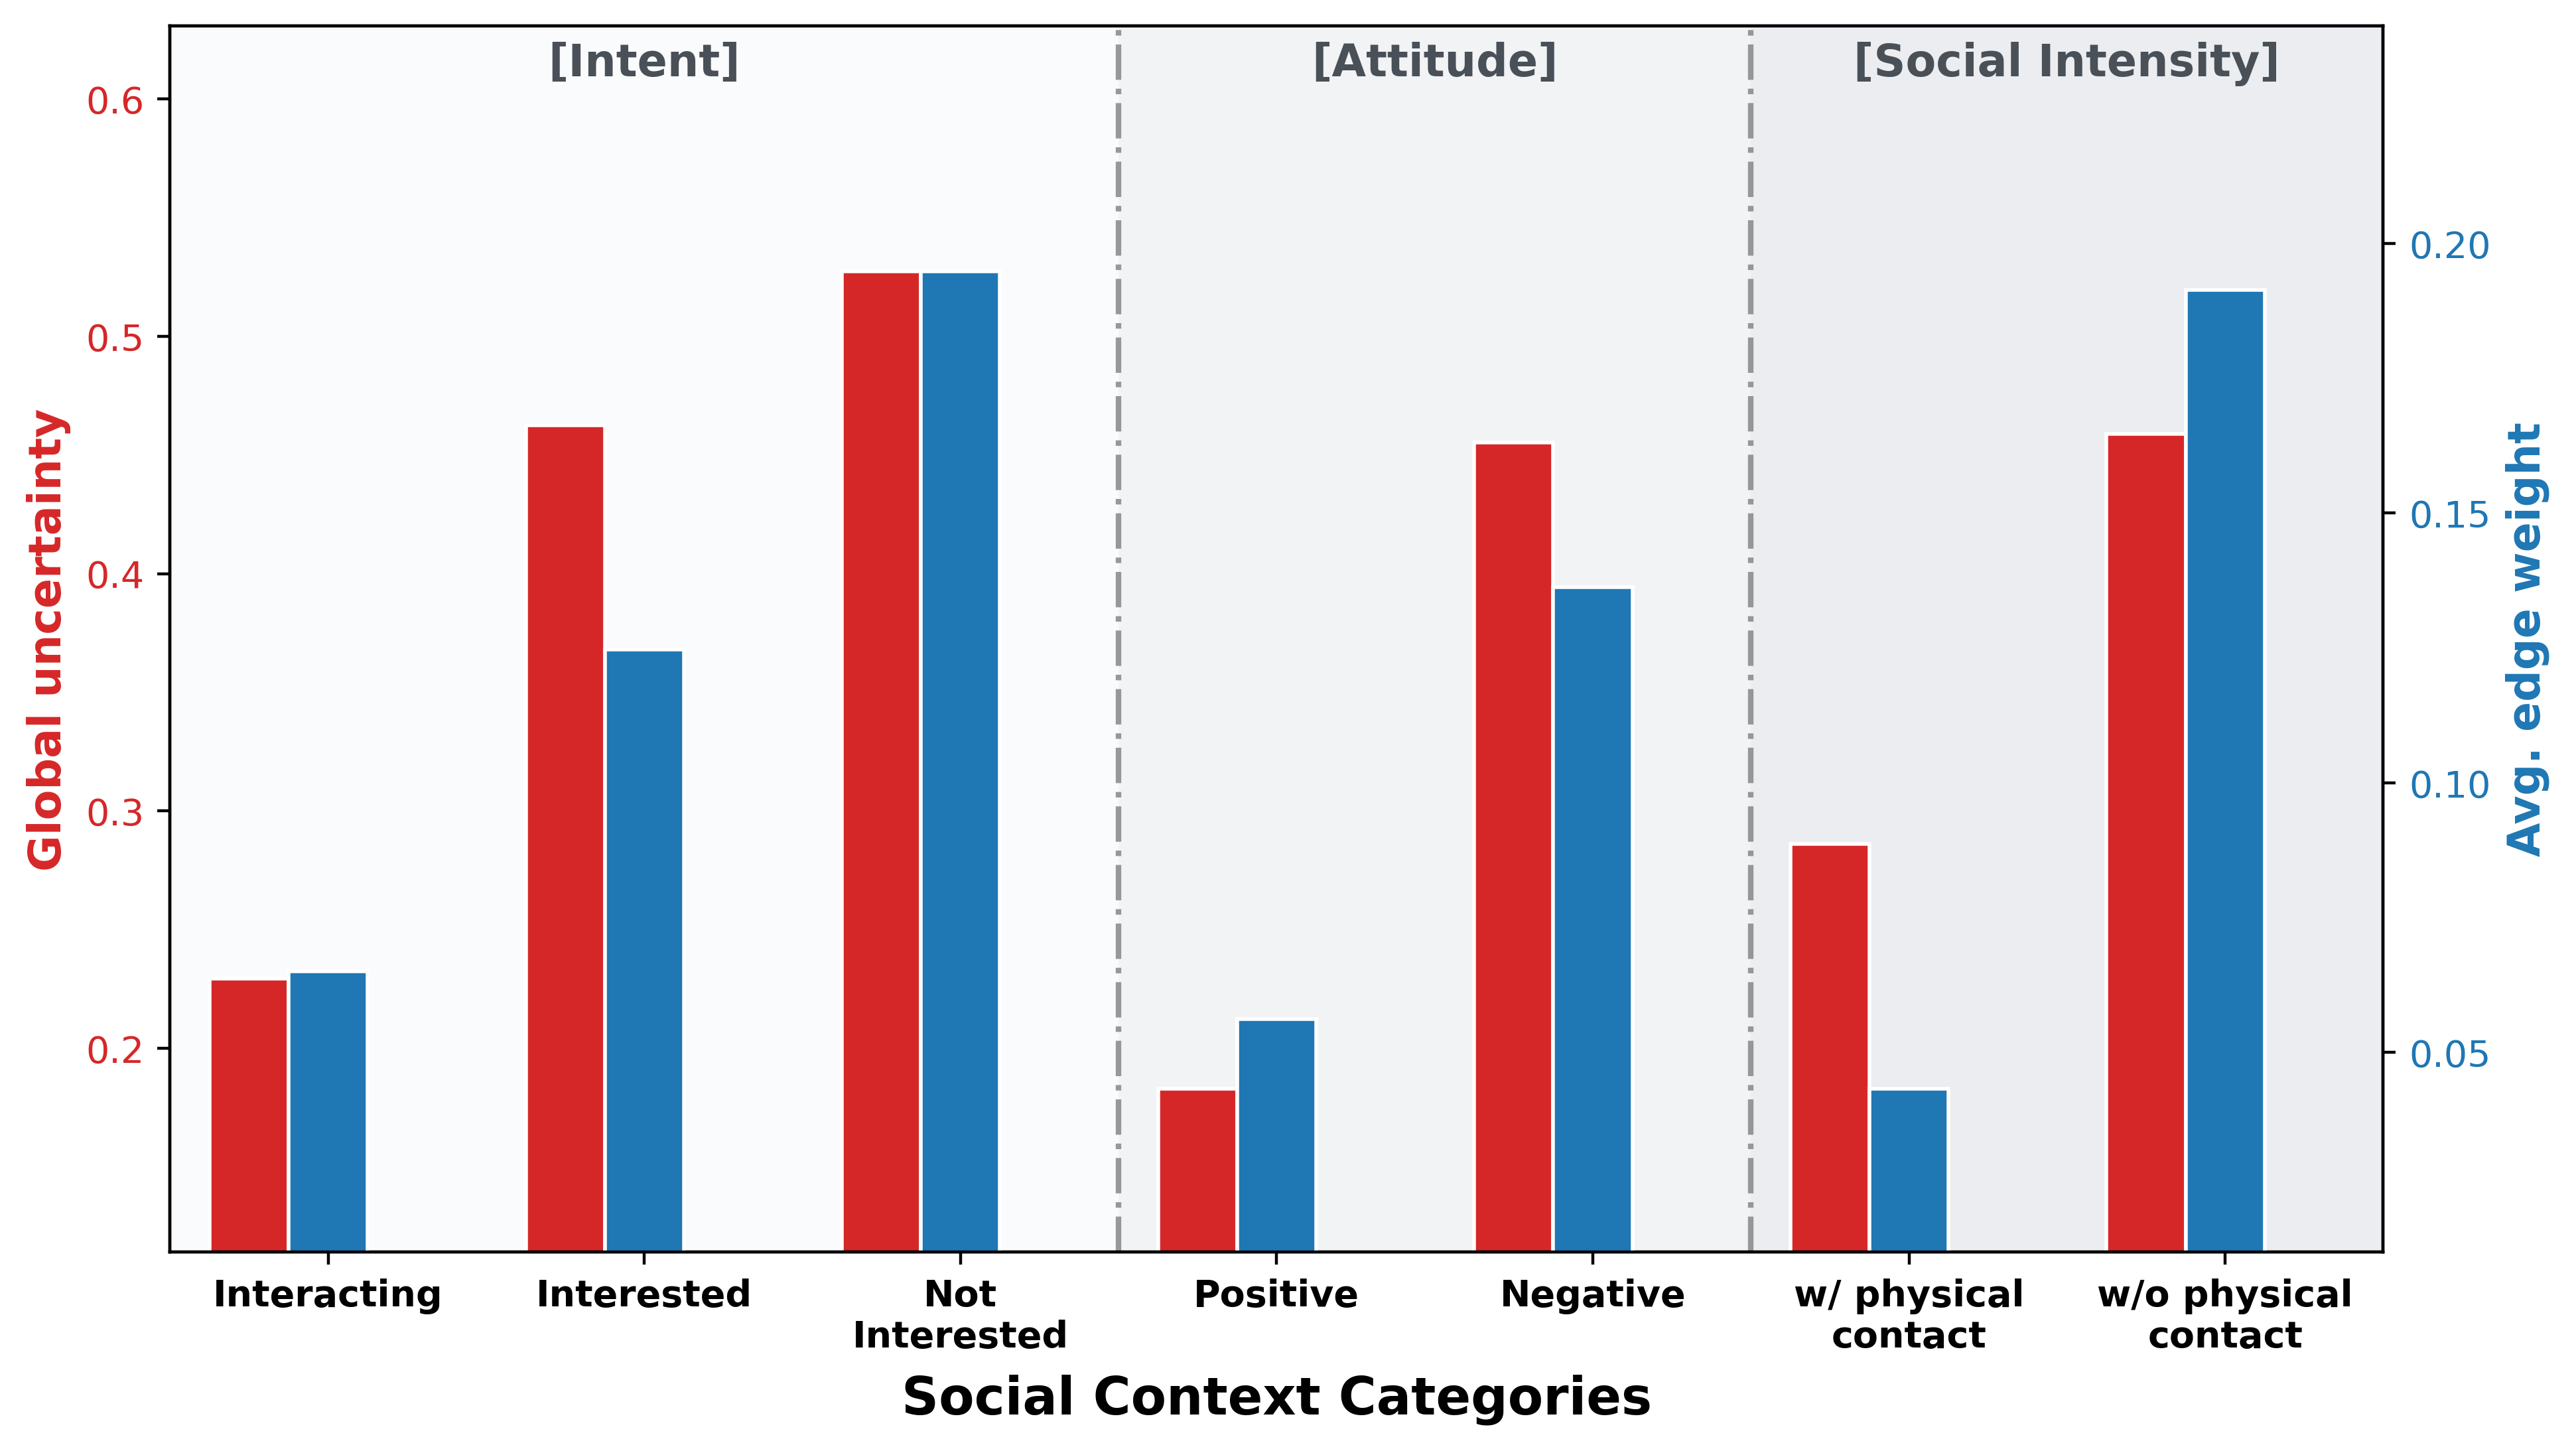

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Loading data
# ==========================================
try:
    df = pd.read_csv('matrices_uncertainty.csv')
except FileNotFoundError:
    print("Error: No matrices_uncertainty.csv，please check path.")
    raise

tasks = ['Contact_Current', 'Contact_Future', 'Intent', 'Attitude', 'Action_Current', 'Action_Future']

masked_edges = [('Contact_Future', 'Contact_Current'), ('Contact_Future', 'Action_Current'),
                ('Action_Future', 'Contact_Current'), ('Action_Future', 'Action_Current')]
valid_cols = [f'Weight_{s}_to_{d}' for s in tasks for d in tasks if s != d and (s, d) not in masked_edges if f'Weight_{s}_to_{d}' in df.columns]

if 'df' in locals():
    df['Global_Avg_Weight'] = df[valid_cols].mean(axis=1)
    uncert_cols = [f'Uncertainty_Entropy_{t}_graph' for t in tasks if f'Uncertainty_Entropy_{t}_graph' in df.columns]
    df['Predictive_Uncertainty'] = df[uncert_cols].mean(axis=1)

    # ==========================================
    # 2. Grouping and filtering according to the new rules
    # ==========================================
    def map_intent(stage):
        if stage == 'Interacting': return 'Interacting'
        elif stage == 'Approaching': return 'Interested'
        elif stage in ['Pre-Interaction', 'Post-Interaction']: return 'Not_Interested'
        else: return np.nan
    df['Custom_Intent'] = df['Stage_Label'].apply(map_intent)

    categories = []
    group_labels = []
    u_vals, gw_vals= [], []

    for cat in ['Interacting', 'Interested', 'Not_Interested']:
        mask = df['Custom_Intent'] == cat
        categories.append(cat.replace('_', '\n'))
        group_labels.append('Intent')
        u_vals.append(df.loc[mask, 'Predictive_Uncertainty'].mean())
        gw_vals.append(df.loc[mask, 'Global_Avg_Weight'].mean())

    for cat in ['Positive', 'Negative']:
        mask = df['Label_Attitude'] == cat
        categories.append(cat)
        group_labels.append('Attitude')
        u_vals.append(df.loc[mask, 'Predictive_Uncertainty'].mean())
        gw_vals.append(df.loc[mask, 'Global_Avg_Weight'].mean())

    for cat in ['Strong_Interaction', 'Weak_Interaction']:
        if cat == 'No_Interaction':
            mask = (df['Intensity_Label'] == cat) & (df['Stage_Label'] != 'No_Interaction')
        else:
            mask = df['Intensity_Label'] == cat

        cat_str = 'w/ physical\ncontact' if cat == 'Strong_Interaction' else 'w/o physical\ncontact'
        categories.append(cat_str)
        group_labels.append('Social Intensity')
        u_vals.append(df.loc[mask, 'Predictive_Uncertainty'].mean())
        gw_vals.append(df.loc[mask, 'Global_Avg_Weight'].mean())

    df_plot = pd.DataFrame({
        'Category': categories, 'Group': group_labels,
        'Uncertainty': u_vals, 'Global_Weight': gw_vals
    })

    # ==========================================
    # 3. Visual design of a three-axis bar chart
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(12, 6), dpi=400)
    fig.subplots_adjust(right=0.82)

    x = np.arange(len(df_plot))
    width = 0.25

    color_u = '#d62728'
    color_gw = '#1f77b4'

    # --- Draw bars ---
    rects1 = ax1.bar(x - width, df_plot['Uncertainty'], width, color=color_u, label='Global uncertainty', edgecolor='white', linewidth=1)
    ax1.set_ylabel('Global uncertainty', color=color_u, fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_u)
    ax2 = ax1.twinx()
    rects2 = ax2.bar(x, df_plot['Global_Weight'], width, color=color_gw, label='Avg. edge weight', edgecolor='white', linewidth=1)
    ax2.set_ylabel('Avg. edge weight', color=color_gw, fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_gw)
    def align_yaxis(ax, data, padding=0.2):
        d_min, d_max = min(data), max(data)
        rng = d_max - d_min
        ax.set_ylim(d_min - rng*padding, d_max + rng*(padding + 0.1))

    align_yaxis(ax1, df_plot['Uncertainty'])
    align_yaxis(ax2, df_plot['Global_Weight'])
    group_counts = df_plot['Group'].value_counts()[df_plot['Group'].unique()]
    current_idx = -0.5
    bg_colors = ['#f8f9fa', '#e9ecef', '#dee2e6']

    for i, (grp_name, count) in enumerate(group_counts.items()):
        ax1.axvspan(current_idx, current_idx + count, facecolor=bg_colors[i], alpha=0.6, zorder=-1)

        center_x = current_idx + count / 2
        ax1.text(center_x, ax1.get_ylim()[1] * 0.99, f"[{grp_name}]",
                 ha='center', va='top', fontsize=12, fontweight='bold', color='#495057')

        if i > 0:
            ax1.axvline(x=current_idx, color='gray', linestyle='-.', linewidth=1.5, alpha=0.8)
        current_idx += count
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_plot['Category'], fontsize=10, fontweight='bold')
    ax1.set_xlabel('Social Context Categories', fontsize=14, fontweight='bold', labelpad=5)
    ax1.set_xlim(-0.5, len(df_plot) - 0.5)
    lines = [rects1, rects2]
    labels = [l.get_label() for l in lines]
    plt.grid(False)
    plt.savefig('social_contexts.png', transparent=True, bbox_inches='tight', pad_inches=0,dpi=400)
    print("Plot saved successfully.")

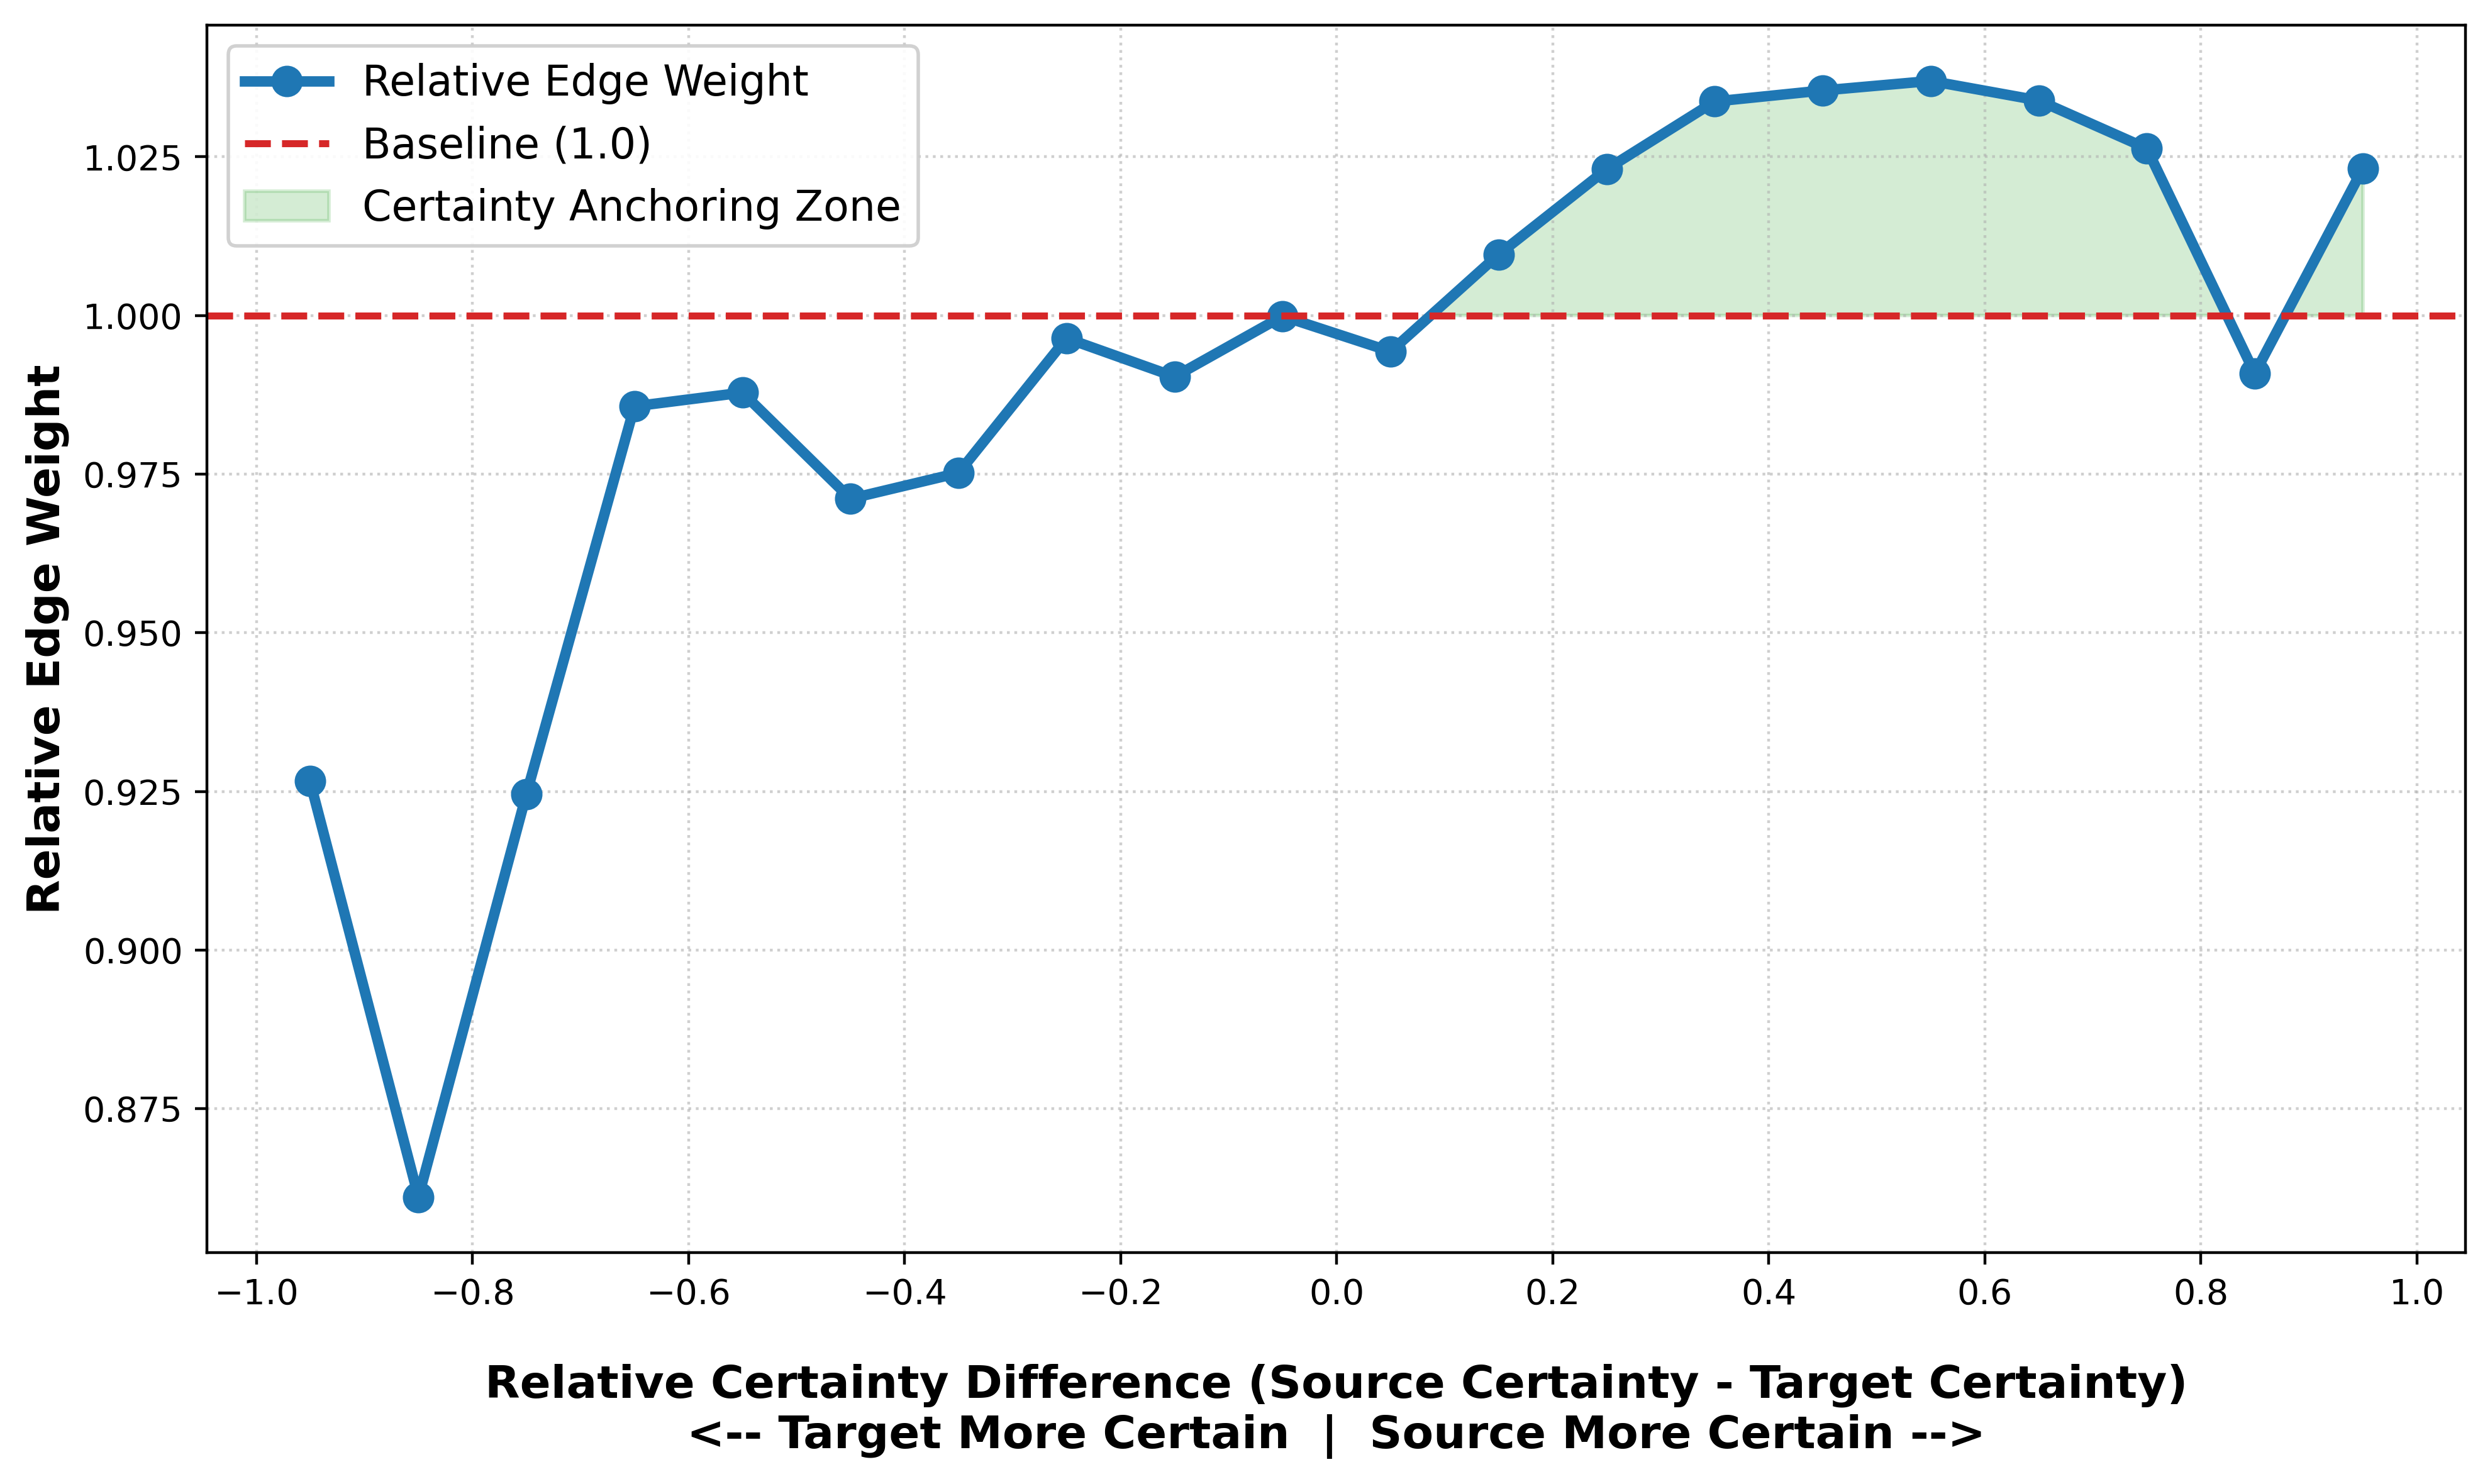

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Loading data
# ==========================================
try:
    df = pd.read_csv('matrices_uncertainty.csv')
except FileNotFoundError:
    print("Error: No matrices_uncertainty.csv，please check path.")
    raise

tasks = ['Contact_Current', 'Contact_Future', 'Intent', 'Attitude', 'Action_Current', 'Action_Future']

# ==========================================
# 2. Calculating relative certainty (Min-Max normalisation)
# ==========================================
rel_cert_cols = {}
for t in tasks:
    col_name = f'Uncertainty_Entropy_{t}_graph_intermediate'
    if col_name in df.columns:
        rel_cert_name = f'Rel_Certainty_{t}'
        min_val = df[col_name].min()
        max_val = df[col_name].max()
        df[rel_cert_name] = 1.0 - (df[col_name] - min_val) / (max_val - min_val + 1e-9)
        rel_cert_cols[t] = rel_cert_name
masked_edges = [
    ('Contact_Future', 'Contact_Current'), ('Contact_Future', 'Action_Current'),
    ('Action_Future', 'Contact_Current'), ('Action_Future', 'Action_Current')
]

valid_weight_cols = [f'Weight_{s}_to_{d}' for s in tasks for d in tasks
                     if s != d and (s, d) not in masked_edges and f'Weight_{s}_to_{d}' in df.columns]

df['Global_Avg_Weight'] = df[valid_weight_cols].mean(axis=1)
edge_data_list = []
for s in tasks:
    for d in tasks:
        if s != d and (s, d) not in masked_edges:
            w_col = f'Weight_{s}_to_{d}'
            if w_col in df.columns and s in rel_cert_cols and d in rel_cert_cols:
                c_s = rel_cert_cols[s]
                c_d = rel_cert_cols[d]
                temp_df = df[[w_col, 'Global_Avg_Weight', c_s, c_d]].copy().dropna()
                temp_df['Relative_Certainty_Diff'] = temp_df[c_s] - temp_df[c_d]
                temp_df['Relative_Weight'] = temp_df[w_col] / (temp_df['Global_Avg_Weight'] + 1e-9)
                edge_data_list.append(temp_df[['Relative_Certainty_Diff', 'Relative_Weight']])
df_edges = pd.concat(edge_data_list, ignore_index=True)

# ==========================================
# 3. Binning
# ==========================================
bins = np.linspace(-1, 1, 21)
df_edges['Diff_Bin'] = pd.cut(df_edges['Relative_Certainty_Diff'], bins=bins, include_lowest=True)
stats = df_edges.groupby('Diff_Bin', observed=False)['Relative_Weight'].mean().reset_index()
stats['Bin_Center'] = stats['Diff_Bin'].apply(lambda x: x.mid).astype(float)
x_data = stats['Bin_Center'].values
y_data = stats['Relative_Weight'].values

# ==========================================
# 4. Visualisation
# ==========================================
global_rel_avg = 1.0
plt.figure(figsize=(10, 6), dpi=400)
plt.plot(x_data, y_data, marker='o', linestyle='-', color='#1f77b4', linewidth=3, markersize=8, label='Relative Edge Weight')
plt.axhline(y=global_rel_avg, color='#d62728', linestyle='--', linewidth=2, label='Baseline (1.0)')
plt.fill_between(x_data, global_rel_avg, y_data, where=(x_data > 0) & (y_data > global_rel_avg),
                 interpolate=True, color='#2ca02c', alpha=0.2, label='Certainty Anchoring Zone')
plt.xlabel('Relative Certainty Difference (Source Certainty - Target Certainty)\n<-- Target More Certain  |  Source More Certain -->',
           fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('Relative Edge Weight', fontsize=13, fontweight='bold')
plt.xticks(np.arange(-1.0, 1.1, 0.2))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig('edge_weight_of_relative_certainty_differences.png', transparent=True, bbox_inches='tight', pad_inches=0, dpi=400)
plt.show()